User Clustering Based on Transaction Behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("bank_transactions_data_2.csv")

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [4]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [5]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"])

df["days_between"] = (df["TransactionDate"] - df["PreviousTransactionDate"]).dt.days.abs()

df["is_debit"] = df["TransactionType"] == "Debit"

I aggregated transaction-level data into user-level features such as total spend, average transaction amount, transaction count, debit ratio, average balance, and average days between transactions.

In [6]:
user_df = df.groupby("AccountID").agg(
    total_spend=("TransactionAmount", "sum"),
    avg_amount=("TransactionAmount", "mean"),
    transaction_count=("TransactionAmount", "count"),
    debit_ratio=("is_debit", "mean"),
    avg_balance=("AccountBalance", "mean"),
    avg_days_between=("days_between", "mean")
).reset_index()

user_df = user_df.fillna(0)

user_df.head()

,AccountID,total_spend,avg_amount,transaction_count,debit_ratio,avg_balance,avg_days_between
0,AC00001,260.76,130.380000,2,1.000000,2915.160000,386.000000
1,AC00002,2056.21,293.744286,7,0.857143,4480.421429,510.571429
2,AC00003,1266.34,253.268000,5,0.800000,7329.568000,576.800000
3,AC00004,2180.08,242.231111,9,0.888889,3340.956667,424.777778
4,AC00005,3131.77,347.974444,9,0.888889,4457.837778,489.777778


I standardized the features, applied PCA for visualization, and used KMeans with 4 clusters to segment users.

In [7]:
X = user_df.drop("AccountID", axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

user_df["cluster"] = clusters
user_df["pca1"] = X_pca[:, 0]
user_df["pca2"] = X_pca[:, 1]

user_df.head()

,AccountID,total_spend,avg_amount,transaction_count,debit_ratio,avg_balance,avg_days_between,cluster,pca1,pca2
0,AC00001,260.76,130.380000,2,1.000000,2915.160000,386.000000,0,-2.136713,-2.114770
1,AC00002,2056.21,293.744286,7,0.857143,4480.421429,510.571429,1,0.852686,0.159854
2,AC00003,1266.34,253.268000,5,0.800000,7329.568000,576.800000,0,-0.425336,1.550171
3,AC00004,2180.08,242.231111,9,0.888889,3340.956667,424.777778,1,1.287515,-0.672316
4,AC00005,3131.77,347.974444,9,0.888889,4457.837778,489.777778,1,2.295714,0.068569


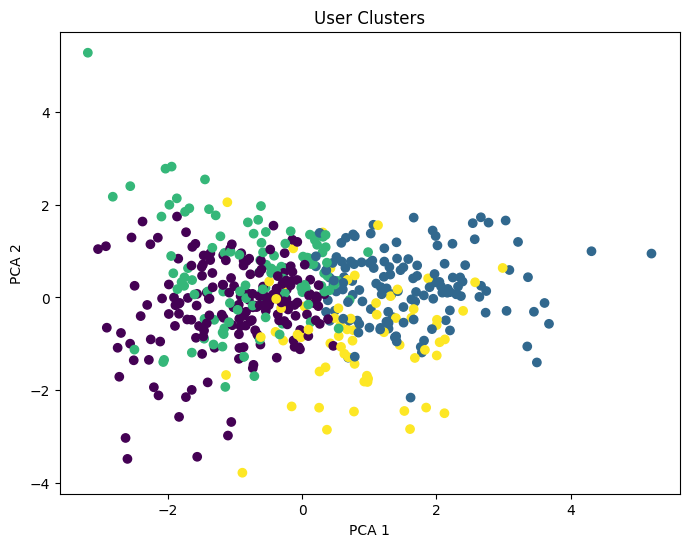

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(user_df["pca1"], user_df["pca2"], c=user_df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("User Clusters")
plt.show()

In [11]:
summary = user_df.groupby("cluster").mean(numeric_only=True)

summary

,total_spend,avg_amount,transaction_count,debit_ratio,avg_balance,avg_days_between,pca1,pca2
cluster,,,,,,,,
0,874.302363,214.739928,4.032967,0.913023,5129.549795,491.134059,-1.001592,-0.188074
1,2592.522313,338.125988,7.776119,0.789629,4880.882020,490.072105,1.582881,0.223185
2,978.416396,225.707244,4.333333,0.528075,5218.530734,485.742103,-0.758126,0.513790
3,1947.504853,529.392495,3.750000,0.807598,5534.927907,473.089951,0.799054,-0.775118
